# Signal level across minutes-bands — performance signals (X) by exposure *(population)*

*Read-only informative artifact. This notebook describes how each candidate
signal sits across minutes-bands (cameo → full game) — the X-side partner to
`points_by_minutes_band.ipynb`, which does the same for the target Y. It produces no
gate, no verdict, no test, and no causal or confound claim. It only describes
where each signal's level sits as minutes rise.*

## Questions this notebook answers (directive)

- **Determine** how each signal's typical level sits across minutes-bands
  (`1-29 / 30-59 / 60+`) — does it rise with time on the pitch or stay flat?
- **Establish** which signals move most from cameo to full-game appearances and
  which barely move.

Here the blocks are **minutes-bands** (cameo → full game) rather than gameweeks.

## Setup

Load the mart, restrict to the **whole season** (GW 1 to the latest completed GW)
and the **participation** population (`minutes > 0`), and split the minutes axis
into three bands: `1-29` (cameo), `30-59` (partial), and `60+` (secure). Bands
collapse at `60+` because FPL's scoring rules do not distinguish `60-89` from
`90` (same appearance / clean-sheet regime), so `60+` is the rule-aligned band.

We deliberately use the **whole featured range** (`minutes > 0`, cameos included),
because the point is to see how a signal sits *across* minutes — so no 60-minute
filter is imposed here.

**Double-gameweek (DGW) note.** DGW rows are **excluded for now**
(`is_dgw == False`): a DGW sums two fixtures into one player-gameweek (~180
minutes, doubled counts), which would otherwise inflate the `60+` band with
fixture-doubling. Per-fixture DGW treatment is the `fixture/` layer's job.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.block_distributions import (
    compute_signal_block_distributions,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()   # DGW excluded for now (single-fixture axis)

POSITIONS = ["GK", "DEF", "MID", "FWD"]

# Minutes-bands are the blocks here (cameo -> full game).
# compute_signal_block_distributions bins by whatever column we pass as gw_column,
# so we pass `minutes` and band ranges. Bands collapse at 60+ because FPL does not
# distinguish 60-89 from 90 (same appearance / clean-sheet regime); with DGW
# excluded, 60+ is a single full match (top bound 999 is just a safe ceiling).
MINUTES_BANDS = {"1-29": (1, 29), "30-59": (30, 59), "60+": (60, 999)}
BAND_ORDER = ["1-29", "30-59", "60+"]

# Raw performance-signal universe (numeric per-GW signals; exclude identity /
# market / structural / context / rolling). `starts` is also excluded here: it is
# mechanically a minutes proxy (a start almost always means 60+ minutes), so on a
# minutes-axis study it is near-circular -- and the starts axis is deferred for now.
_EXCLUDE = {
    "player_id", "gw", "position_code", "team_id",
    "purchase_price", "minutes", "total_points", "starts",
    "is_bgw", "is_dgw", "is_warmup_gw",
    "fdr_avg", "xgc", "home_count", "away_count", "fixture_count",
    "is_live", "is_next", "is_previous", "finished",
    "transfers_in", "transfers_out", "ownership_count",
}
SIGNALS = sorted(
    c for c in df.select_dtypes(include="number").columns
    if c not in _EXCLUDE and "_roll" not in c and not c.endswith("_trend")
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0, DGW excluded (participation, not a performance gate), n = {len(df):,} player-gameweeks")
print("Minutes-bands:", MINUTES_BANDS)
print(f"Signals ({len(SIGNALS)}):", SIGNALS)

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0, DGW excluded (participation, not a performance gate), n = 11,190 player-gameweeks
Minutes-bands: {'1-29': (1, 29), '30-59': (30, 59), '60+': (60, 999)}
Signals (23): ['assists', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'own_goals', 'penalties_missed', 'penalties_saved', 'recoveries', 'red_cards', 'saves', 'tackles', 'threat', 'xa', 'xg', 'xgi', 'yellow_cards']


## (a) Signal distribution across minutes-bands, by position

**What we measure** — for every (signal, position) pair, the signal's median /
IQR / p90 within each minutes-band, via `compute_signal_block_distributions`
(binning on `minutes` instead of gameweek). One row per (signal, position, band);
`n` per cell is shown so thin bands are visible.

**What it means** — this is each signal's level read three times along the minutes
axis. Reading a row left-to-right (`1-29` → `60+`) shows whether the signal's
typical level rises as the player spends more time on the pitch, or sits flat.

**What it doesn't mean** — this is a **description** of how the signal sits across
minutes-bands, season-pooled (DGW excluded). It is **not** a claim that minutes drives
or confounds the signal's relationship to points — explaining *why* a signal rises
with minutes, or what that does to its link with `total_points`, is a Diagnostic-tier
question, out of scope for this descriptive notebook.

**Guiding question (directive)** — *Determine how each signal's typical level sits
across minutes-bands — does it rise with minutes on the pitch, or stay flat?*

In [2]:
band_dist = compute_signal_block_distributions(
    df, SIGNALS, POSITIONS, gw_column="minutes", gw_blocks=MINUTES_BANDS,
)
# NOTE: the kernel is generic -- here 'min_gw'/'max_gw' are the minute-band bounds,
# and 'block' is the band name. Order for readability.
band_dist["block"] = pd.Categorical(band_dist["block"], categories=BAND_ORDER, ordered=True)
band_dist["position"] = pd.Categorical(band_dist["position"], categories=POSITIONS, ordered=True)
band_dist["signal"] = pd.Categorical(band_dist["signal"], categories=SIGNALS, ordered=True)
band_dist = band_dist.sort_values(["signal", "position", "block"]).reset_index(drop=True)
display(
    band_dist[["signal", "position", "block", "n", "median", "iqr", "p90"]]
    .rename(columns={"block": "minutes_band"})
)

,signal,position,minutes_band,n,median,iqr,p90
0,assists,GK,1-29,4,NaN,NaN,NaN
1,assists,GK,30-59,6,NaN,NaN,NaN
2,assists,GK,60+,737,0.000,0.000,0.000
3,assists,DEF,1-29,618,0.000,0.000,0.000
4,assists,DEF,30-59,283,0.000,0.000,0.000
...,...,...,...,...,...,...,...
271,yellow_cards,MID,30-59,597,0.000,0.000,1.000
272,yellow_cards,MID,60+,3184,0.000,0.000,1.000
273,yellow_cards,FWD,1-29,504,0.000,0.000,0.000
274,yellow_cards,FWD,30-59,144,0.000,0.000,0.000


In [3]:
# Median-by-band pivot: read each (signal x position) row left-to-right to see how
# the signal's typical level moves from cameo (1-29) to full game (60+).
median_pivot = band_dist.pivot_table(
    index=["signal", "position"], columns="block", values="median", observed=True,
)[BAND_ORDER]
display(median_pivot.round(3))

block                  1-29  30-59   60+
signal       position                   
assists      GK         NaN    NaN 0.000
             DEF      0.000  0.000 0.000
             MID      0.000  0.000 0.000
             FWD      0.000  0.000 0.000
bonus        GK         NaN    NaN 0.000
...                     ...    ...   ...
xgi          FWD      0.010  0.080 0.290
yellow_cards GK         NaN    NaN 0.000
             DEF      0.000  0.000 0.000
             MID      0.000  0.000 0.000
             FWD      0.000  0.000 0.000

[92 rows x 3 columns]

## (b) Which signals rise with minutes — per position

**What we measure** — for **each position**, the signals whose typical level
climbs most from cameo (`1-29`) to full game (`60+`): `Δmedian = median(60+) −
median(1-29)`, top 5 per position as horizontal bars. **Per position, not
pooled** — the signals are position-specific (a GK's `saves`, a DEF's
`clearances`, a FWD's `xg` are not comparable, and pooling buries them in zeros).

**What it means** — each panel is that position's "what grows as minutes rise"
list. The climbers are per-match accumulating quantities, so their typical level
builds with time on the pitch. The signals that **don't** move (Δ ≈ 0) are
*listed beneath* each panel rather than plotted — they are the rare-event stats
(goals, assists, cards, …) whose median is 0 in every band. There are **no
negative movers** at any position (nothing scores higher in cameos), so a "bottom
5" would just be five arbitrary zeros — hence the list instead.

**What it doesn't mean** — pure description; the climb is observed, not explained
or tested, and is confounded with player quality. Median only — tail movement for
the rare-event signals lives in the (a) `p90` column.

**Guiding question (directive)** — *Establish, per position, which signals move
most from cameo to full-game appearances and which barely move.*

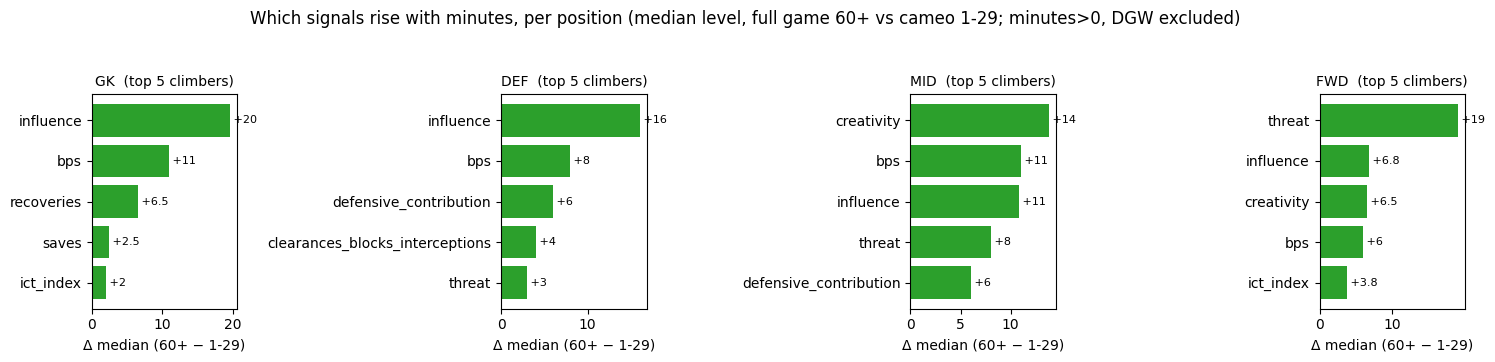

GK: flat (Δ≈0, do not move with minutes) — assists, xgi, xg, xa, threat, tackles, red_cards, own_goals, penalties_saved, penalties_missed, bonus, goals_scored, goals_conceded, defensive_contribution, creativity, clean_sheets, yellow_cards
DEF: flat (Δ≈0, do not move with minutes) — xgi, xa, assists, saves, xg, own_goals, red_cards, penalties_saved, penalties_missed, bonus, goals_scored, clean_sheets, yellow_cards
MID: flat (Δ≈0, do not move with minutes) — assists, saves, own_goals, red_cards, penalties_saved, penalties_missed, bonus, goals_scored, clean_sheets, yellow_cards
FWD: flat (Δ≈0, do not move with minutes) — xa, assists, saves, tackles, own_goals, red_cards, penalties_saved, penalties_missed, bonus, goals_scored, clean_sheets, yellow_cards


In [4]:
# Per-position climb: for EACH position, the signals whose typical level rises
# most from cameo (1-29) to full game (60+): Δmedian = median(60+) - median(1-29).
# Per position (NOT pooled) -- the signals are position-specific (a GK's saves and
# a FWD's threat are not comparable, and pooling buries them in zeros). Top-5
# climbers per position are plotted; the flat ones (Δ≈0) are listed beneath
# rather than plotted -- there are no negative movers.
def _bandname(mn):
    return "1-29" if mn < 30 else "30-59" if mn < 60 else "60+"

w = df.copy()
w["band"] = w["minutes"].astype(int).map(_bandname)
TOP_N = 5

fig, axes = plt.subplots(1, len(POSITIONS), figsize=(15, 3.4))
flat_by_pos = {}
for ax, pos in zip(axes, POSITIONS):
    med = w[w.position == pos].groupby("band")[SIGNALS].median().reindex(BAND_ORDER).astype(float)
    delta = (med.loc["60+"] - med.loc["1-29"]).sort_values(ascending=False)
    top = delta.head(TOP_N).iloc[::-1]            # reverse so the biggest is on top
    ax.barh(top.index, top.to_numpy(), color="#2ca02c")
    for y, v in enumerate(top.to_numpy()):
        ax.text(v, y, f" {v:+.2g}", va="center", fontsize=8)
    ax.set_title(f"{pos}  (top {TOP_N} climbers)", fontsize=10)
    ax.set_xlabel("Δ median (60+ − 1-29)")
    flat_by_pos[pos] = delta[delta.abs() < 0.05].index.tolist()
fig.suptitle("Which signals rise with minutes, per position "
             "(median level, full game 60+ vs cameo 1-29; minutes>0, DGW excluded)", y=1.05)
plt.tight_layout()
plt.show()

for pos in POSITIONS:
    print(f"{pos}: flat (Δ≈0, do not move with minutes) — {', '.join(flat_by_pos[pos])}")

## What the signal-by-minutes picture looks like

Plain-language description (not a verdict, not a test, not an explanation):

- **Per position, the climbers are the per-match accumulating signals**, and the
  ranking is position-specific: **GK** `influence` (+20 median), `bps` (+11),
  `recoveries` (+6.5); **DEF** `influence` (+16), `bps` (+8),
  `defensive_contribution` (+6), `clearances_blocks_interceptions` (+4); **MID**
  `creativity` (+14), `bps` (+11), `influence` (+11), `threat` (+8); **FWD**
  `threat` (+19), `influence` (+6.8), `creativity` (+6.5). These accumulate
  through involvement, so they grow with time on the pitch.
- **The rare-event signals are flat at the median, every position.**
  `goals_scored`, `assists`, `clean_sheets`, cards, `saves`, `penalties_*` show
  `Δmedian = 0` because their median is **0 in every band** (most appearances
  return none, regardless of minutes). Any movement is in the **tail**, not the
  median — read the `p90` column in the (a) table, not the Δ bars.
- **No signal scores higher in cameos** — there are no negative movers at any
  position, so the picture is "rises with minutes" or "flat," never "fades."

All figures are **whole-season**, season-pooled **within each position** over the
**participation** population (`minutes > 0`), with **DGW excluded**
(`is_dgw == False`). This notebook **describes** how each signal sits across
minutes-bands; *whether* minutes drives a signal, or what that does to its
relationship with `total_points`, is a Diagnostic-tier question, deliberately out
of scope here.